In [1]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Outputs directory:", OUTPUTS_DIR)

Project root: /Users/chelsearose/Documents/GitHub/county-obesity-prediction
Outputs directory: /Users/chelsearose/Documents/GitHub/county-obesity-prediction/outputs


In [2]:
lr_summary = pd.read_csv(
    OUTPUTS_DIR / "linear_regression" / "lr_performance_summary.csv"
)

rf_summary = pd.read_csv(
    OUTPUTS_DIR / "random_forest" / "rf_performance_summary.csv"
)

xgb_summary = pd.read_csv(
    OUTPUTS_DIR / "xgboost" / "xgb_performance_summary.csv"
)

stacking_summary = pd.read_csv(
    OUTPUTS_DIR / "stacking" / "stacking_performance_summary.csv"
)

print("Linear Regression")
display(lr_summary)

print("Random Forest")
display(rf_summary)

print("XGBoost")
display(xgb_summary)

print("Stacking Ensemble")
display(stacking_summary)

Linear Regression


,Metric,Mean,SD
0,MAE,2.410543,0.078074
1,RMSE,3.095610,0.111735
2,R2,0.549115,0.040653


Random Forest


,Metric,Mean,SD
0,MAE,2.223054,0.113463
1,RMSE,2.883200,0.164753
2,R2,0.609797,0.029655


XGBoost


,Metric,Mean,SD
0,MAE,2.197069,0.095764
1,RMSE,2.819254,0.149653
2,R2,0.626617,0.031132


Stacking Ensemble


,Metric,Mean,SD
0,MAE,2.181742,0.091564
1,RMSE,2.802686,0.143761
2,R2,0.630895,0.031466


In [3]:
model_summaries = {
    "Linear Regression": lr_summary,
    "Random Forest": rf_summary,
    "XGBoost": xgb_summary,
    "Stacking Ensemble": stacking_summary
}

comparison_rows = []

for model_name, summary_df in model_summaries.items():
    row = {"Model": model_name}

    for _, metric_row in summary_df.iterrows():
        metric = metric_row["Metric"]
        row[f"{metric}_Mean"] = metric_row["Mean"]
        row[f"{metric}_SD"] = metric_row["SD"]

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df.round(4))

,Model,MAE_Mean,MAE_SD,RMSE_Mean,RMSE_SD,R2_Mean,R2_SD
0,Linear Regression,2.4105,0.0781,3.0956,0.1117,0.5491,0.0407
1,Random Forest,2.2231,0.1135,2.8832,0.1648,0.6098,0.0297
2,XGBoost,2.1971,0.0958,2.8193,0.1497,0.6266,0.0311
3,Stacking Ensemble,2.1817,0.0916,2.8027,0.1438,0.6309,0.0315


In [4]:
stacking_row = comparison_df[
    comparison_df["Model"] == "Stacking Ensemble"
].iloc[0]

improvement_rows = []

for _, row in comparison_df.iterrows():
    if row["Model"] == "Stacking Ensemble":
        continue

    improvement_rows.append({
        "Compared_To": row["Model"],

        "MAE_Reduction": row["MAE_Mean"] - stacking_row["MAE_Mean"],
        "MAE_Reduction_Pct": (
            (row["MAE_Mean"] - stacking_row["MAE_Mean"])
            / row["MAE_Mean"] * 100
        ),

        "RMSE_Reduction": row["RMSE_Mean"] - stacking_row["RMSE_Mean"],
        "RMSE_Reduction_Pct": (
            (row["RMSE_Mean"] - stacking_row["RMSE_Mean"])
            / row["RMSE_Mean"] * 100
        ),

        "R2_Increase": stacking_row["R2_Mean"] - row["R2_Mean"]
    })

improvement_df = pd.DataFrame(improvement_rows)

display(improvement_df.round(4))

,Compared_To,MAE_Reduction,MAE_Reduction_Pct,RMSE_Reduction,RMSE_Reduction_Pct,R2_Increase
0,Linear Regression,0.2288,9.4917,0.2929,9.4626,0.0818
1,Random Forest,0.0413,1.8583,0.0805,2.7925,0.0211
2,XGBoost,0.0153,0.6976,0.0166,0.5877,0.0043


In [5]:
lr_folds = pd.read_csv(
    OUTPUTS_DIR / "linear_regression" / "lr_outer_fold_metrics.csv"
)

rf_folds = pd.read_csv(
    OUTPUTS_DIR / "random_forest" / "rf_outer_fold_metrics.csv"
)

xgb_folds = pd.read_csv(
    OUTPUTS_DIR / "xgboost" / "xgb_outer_fold_metrics.csv"
)

stacking_folds = pd.read_csv(
    OUTPUTS_DIR / "stacking" / "stacking_outer_fold_metrics.csv"
)

print("Linear Regression columns:", lr_folds.columns.tolist())
print("Random Forest columns:", rf_folds.columns.tolist())
print("XGBoost columns:", xgb_folds.columns.tolist())
print("Stacking columns:", stacking_folds.columns.tolist())

print("\nStacking outer-fold results:")
display(stacking_folds)

Linear Regression columns: ['fold', 'MAE', 'RMSE', 'R2']
Random Forest columns: ['fold', 'MAE', 'RMSE', 'R2']
XGBoost columns: ['fold', 'MAE', 'RMSE', 'R2']
Stacking columns: ['Outer_Fold', 'MAE', 'RMSE', 'R2']

Stacking outer-fold results:


,Outer_Fold,MAE,RMSE,R2
0,1,2.282038,2.916613,0.617743
1,2,2.233439,2.860288,0.649754
2,3,2.220196,2.920911,0.611219
3,4,2.062115,2.585645,0.676267
4,5,2.110925,2.729972,0.599492


In [6]:
# Standardize fold column name
stacking_folds = stacking_folds.rename(columns={"Outer_Fold": "fold"})

# Add model labels
lr_folds["Model"] = "Linear Regression"
rf_folds["Model"] = "Random Forest"
xgb_folds["Model"] = "XGBoost"
stacking_folds["Model"] = "Stacking Ensemble"

# Combine all outer-fold results
all_fold_results = pd.concat(
    [lr_folds, rf_folds, xgb_folds, stacking_folds],
    ignore_index=True
)

# Arrange columns
all_fold_results = all_fold_results[
    ["fold", "Model", "MAE", "RMSE", "R2"]
]

display(
    all_fold_results
    .sort_values(["fold", "Model"])
    .round(4)
)

,fold,Model,MAE,RMSE,R2
0,1,Linear Regression,2.4749,3.1798,0.5456
5,1,Random Forest,2.2954,2.9629,0.6055
15,1,Stacking Ensemble,2.2820,2.9166,0.6177
10,1,XGBoost,2.3130,2.9472,0.6097
1,2,Linear Regression,2.4559,3.0924,0.5906
6,2,Random Forest,2.3576,3.0443,0.6032
16,2,Stacking Ensemble,2.2334,2.8603,0.6498
11,2,XGBoost,2.2414,2.8792,0.6451
2,3,Linear Regression,2.4488,3.2093,0.5307
7,3,Random Forest,2.2401,2.9819,0.5948


In [7]:
best_by_fold = []

for fold in sorted(all_fold_results["fold"].unique()):
    fold_data = all_fold_results[
        all_fold_results["fold"] == fold
    ]

    best_by_fold.append({
        "Fold": fold,
        "Best_MAE": fold_data.loc[
            fold_data["MAE"].idxmin(), "Model"
        ],
        "Best_RMSE": fold_data.loc[
            fold_data["RMSE"].idxmin(), "Model"
        ],
        "Best_R2": fold_data.loc[
            fold_data["R2"].idxmax(), "Model"
        ]
    })

best_by_fold_df = pd.DataFrame(best_by_fold)

display(best_by_fold_df)

,Fold,Best_MAE,Best_RMSE,Best_R2
0,1,Stacking Ensemble,Stacking Ensemble,Stacking Ensemble
1,2,Stacking Ensemble,Stacking Ensemble,Stacking Ensemble
2,3,Stacking Ensemble,Stacking Ensemble,Stacking Ensemble
3,4,Stacking Ensemble,Stacking Ensemble,Stacking Ensemble
4,5,Stacking Ensemble,Stacking Ensemble,Stacking Ensemble


Matplotlib is building the font cache; this may take a moment.


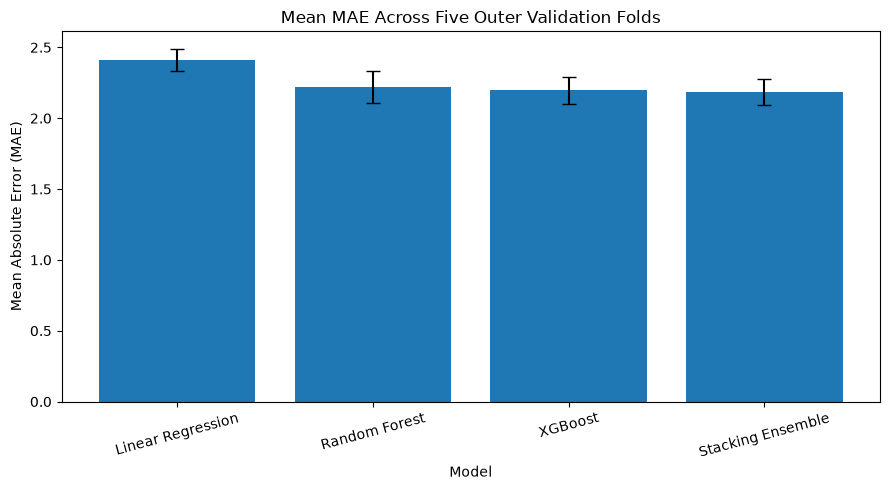

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["MAE_Mean"],
    yerr=comparison_df["MAE_SD"],
    capsize=5
)

plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")
plt.title("Mean MAE Across Five Outer Validation Folds")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

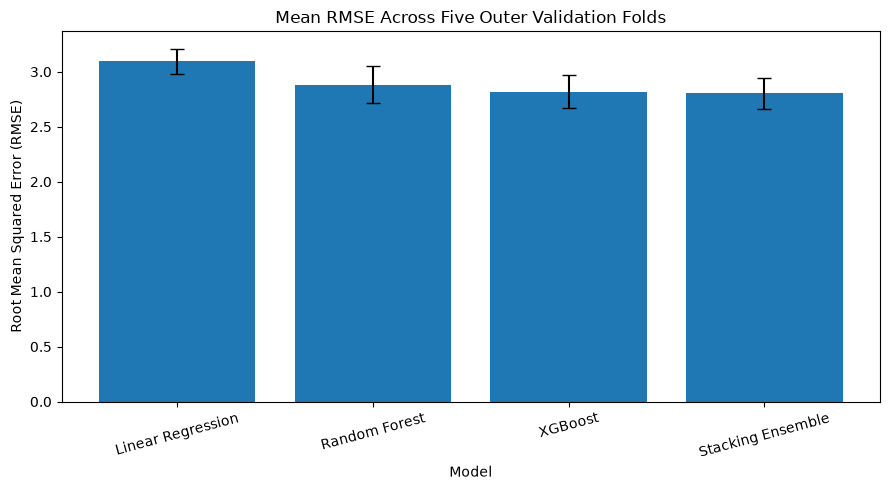

In [9]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["RMSE_Mean"],
    yerr=comparison_df["RMSE_SD"],
    capsize=5
)

plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xlabel("Model")
plt.title("Mean RMSE Across Five Outer Validation Folds")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

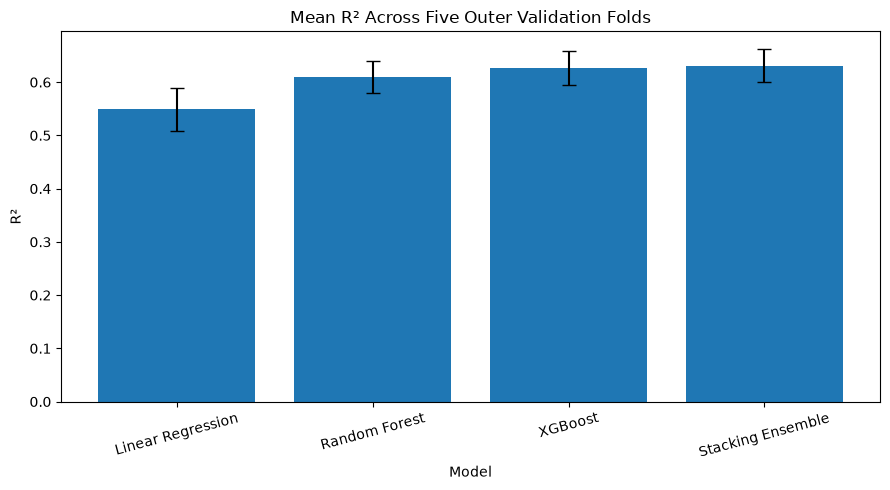

In [10]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["R2_Mean"],
    yerr=comparison_df["R2_SD"],
    capsize=5
)

plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Mean R² Across Five Outer Validation Folds")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [11]:
COMPARISON_OUTPUT_DIR = OUTPUTS_DIR / "model_comparison"
COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save overall mean ± SD comparison
comparison_df.to_csv(
    COMPARISON_OUTPUT_DIR / "model_performance_comparison.csv",
    index=False
)

# Save stacking improvement over each individual model
improvement_df.to_csv(
    COMPARISON_OUTPUT_DIR / "stacking_improvement.csv",
    index=False
)

# Save all outer-fold results
all_fold_results.to_csv(
    COMPARISON_OUTPUT_DIR / "all_model_outer_fold_metrics.csv",
    index=False
)

# Save best model for each metric in each fold
best_by_fold_df.to_csv(
    COMPARISON_OUTPUT_DIR / "best_model_by_fold.csv",
    index=False
)

print("Model comparison outputs saved:")
for file in sorted(COMPARISON_OUTPUT_DIR.iterdir()):
    print("-", file.name)

Model comparison outputs saved:
- all_model_outer_fold_metrics.csv
- best_model_by_fold.csv
- model_performance_comparison.csv
- stacking_improvement.csv


In [12]:
best_mae_model = comparison_df.loc[
    comparison_df["MAE_Mean"].idxmin(), "Model"
]

best_rmse_model = comparison_df.loc[
    comparison_df["RMSE_Mean"].idxmin(), "Model"
]

best_r2_model = comparison_df.loc[
    comparison_df["R2_Mean"].idxmax(), "Model"
]

print("Final Model Comparison")
print("----------------------")
print("Lowest mean MAE :", best_mae_model)
print("Lowest mean RMSE:", best_rmse_model)
print("Highest mean R² :", best_r2_model)

print("\nStacking fold wins:")
print("MAE :", (best_by_fold_df["Best_MAE"] == "Stacking Ensemble").sum(), "/ 5")
print("RMSE:", (best_by_fold_df["Best_RMSE"] == "Stacking Ensemble").sum(), "/ 5")
print("R²  :", (best_by_fold_df["Best_R2"] == "Stacking Ensemble").sum(), "/ 5")

Final Model Comparison
----------------------
Lowest mean MAE : Stacking Ensemble
Lowest mean RMSE: Stacking Ensemble
Highest mean R² : Stacking Ensemble

Stacking fold wins:
MAE : 5 / 5
RMSE: 5 / 5
R²  : 5 / 5
